In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)



In [2]:
df = pd.read_csv("../../Weekend Project/Project 2/loan_default_dataset.csv")

df_clean = df.copy()
df_clean["home_ownership"] = df_clean["home_ownership"].str.upper().str.strip()
df_clean["purpose"] = df_clean["purpose"].str.lower().str.strip()
df_clean.loc[(df_clean["age"] < 18) | (df_clean["age"] > 100), "age"] = np.nan

numeric_cols = [
    "age", "annual_income", "credit_score", "loan_amount",
    "loan_term_months", "interest_rate", "debt_to_income",
    "employment_length_years", "num_open_accounts", "num_late_payments_2yrs"
]
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

df_encoded = pd.get_dummies(df_clean, columns=["home_ownership", "purpose"], dtype=int)

print(f"cleaned and encoded shape: {df_encoded.shape}")

cleaned and encoded shape: (6015, 21)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = "default"
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")

X_train: (4812, 20)
X_test : (1203, 20)


In [4]:
X_train_tensor = torch.FloatTensor(X_train_scaled.copy())
y_train_tensor = torch.LongTensor(y_train.values.copy())
X_test_tensor = torch.FloatTensor(X_test_scaled.copy())
y_test_tensor = torch.LongTensor(y_test.values.copy())

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}")

train batches: 76, val batches: 19


In [5]:
class BaselineMLP(nn.Module):
    def __init__(self, input_size):
        super(BaselineMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output(x)
        return x

print("BaselineMLP defined")

BaselineMLP defined


In [6]:
class RegularizedMLP(nn.Module):
    def __init__(self, input_size):
        super(RegularizedMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)

        self.layer2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.3)

        self.output = nn.Linear(16, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.output(x)
        return x

print("RegularizedMLP defined")

RegularizedMLP defined


In [7]:
def train_model(model, train_loader, val_loader, epochs=30):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        # === TRAINING ===
        model.train()
        running_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * batch_X.size(0)
        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_loss_history.append(avg_train_loss)

        # === VALIDATION ===
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                running_val_loss += loss.item() * batch_X.size(0)
        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_loss_history.append(avg_val_loss)

    return train_loss_history, val_loss_history

print("training function ready")

training function ready


In [8]:
input_size = X_train_tensor.shape[1]

torch.manual_seed(SEED)
baseline_model = BaselineMLP(input_size)
baseline_train_loss, baseline_val_loss = train_model(baseline_model, train_loader, val_loader, epochs=30)

print(f"Baseline final train loss: {baseline_train_loss[-1]:.4f}")
print(f"Baseline final val loss  : {baseline_val_loss[-1]:.4f}")
print(f"Baseline overfitting gap : {baseline_val_loss[-1] - baseline_train_loss[-1]:.4f}")

Baseline final train loss: 0.3350
Baseline final val loss  : 0.3761
Baseline overfitting gap : 0.0411


In [9]:
torch.manual_seed(SEED)
regularized_model = RegularizedMLP(input_size)
reg_train_loss, reg_val_loss = train_model(regularized_model, train_loader, val_loader, epochs=30)

print(f"Regularized final train loss: {reg_train_loss[-1]:.4f}")
print(f"Regularized final val loss  : {reg_val_loss[-1]:.4f}")
print(f"Regularized overfitting gap : {reg_val_loss[-1] - reg_train_loss[-1]:.4f}")

Regularized final train loss: 0.3774
Regularized final val loss  : 0.3687
Regularized overfitting gap : -0.0088


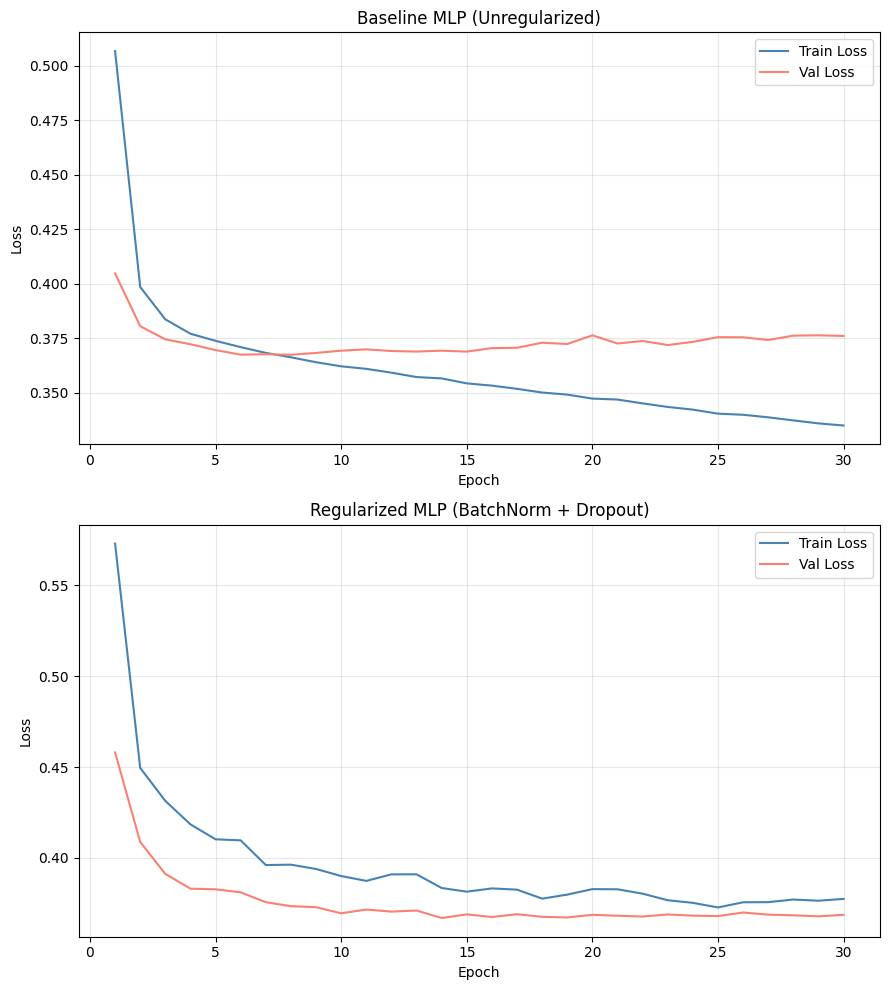

comparison plot saved


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 10))

axes[0].plot(range(1, 31), baseline_train_loss, label="Train Loss", color="steelblue")
axes[0].plot(range(1, 31), baseline_val_loss, label="Val Loss", color="salmon")
axes[0].set_title("Baseline MLP (Unregularized)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 31), reg_train_loss, label="Train Loss", color="steelblue")
axes[1].plot(range(1, 31), reg_val_loss, label="Val Loss", color="salmon")
axes[1].set_title("Regularized MLP (BatchNorm + Dropout)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_vs_regularized_loss.png")
plt.show()
print("comparison plot saved")

In [11]:
def get_accuracy(model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean()
    return accuracy.item()

baseline_acc = get_accuracy(baseline_model, X_test_tensor, y_test_tensor)
reg_acc = get_accuracy(regularized_model, X_test_tensor, y_test_tensor)

print(f"Baseline MLP Test Accuracy    : {baseline_acc:.4f}")
print(f"Regularized MLP Test Accuracy : {reg_acc:.4f}")

Baseline MLP Test Accuracy    : 0.8421
Regularized MLP Test Accuracy : 0.8387
